# Olympics Data Analysis

## Objective
This notebook performs a complete exploratory data analysis (EDA) of the Olympics athlete dataset and the related NOC → Region mapping dataset.

### Analysis workflow
1. Load and understand the datasets
2. Check structure, data types, missing values and duplicates
3. Investigate missing values before making cleaning decisions
4. Clean text and numeric columns
5. Merge athlete data with the Region mapping
6. Create analysis-ready subsets
7. Perform univariate, bivariate and historical analysis
8. Analyze medals, countries/regions, athletes, sports, gender and age
9. Investigate the 2026 records separately
10. Generate visualizations and summarize insights
11. Export cleaned/analysis-ready datasets

> **Important:** Missing `Medal` values are not automatically errors. They generally represent participation without a medal, so medal rows are separated from the full participation dataset instead of deleting all missing values.


## Dataset files

Place these two files in the same folder as this notebook:

- `all_athlete_games.csv`
- `all_regions.csv`

The first dataset contains athlete/game-level records. The second maps Olympic NOC codes to human-readable regions.


In [1]:
# 1. Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
# 2. Load datasets

games = pd.read_csv(
    "all_athlete_games.csv",
    low_memory=False
)

regions = pd.read_csv(
    "all_regions.csv"
)

print("Games shape:", games.shape)
print("Regions shape:", regions.shape)


Games shape: (300266, 14)
Regions shape: (234, 2)


In [3]:
# 3. First look at both datasets

display(games.head())
display(regions.head())


,Entry ID,Name,Gender,Age,Team,NOC,Year,Season,City,Sport,Event,Medal,Sport Disciplines,Event List
0,1,Aristidis Akratopoulos,Male,NaN,Greece,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,NaN,NaN,NaN
1,2,Aristidis Akratopoulos,Male,NaN,Greece-3,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,NaN,NaN,NaN
2,3,"Konstantinos ""Kostas"" Akratopoulos",Male,NaN,Greece,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,NaN,NaN,NaN
3,4,"Konstantinos ""Kostas"" Akratopoulos",Male,NaN,Greece-3,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,NaN,NaN,NaN
4,5,Anastasios Andreou,Male,NaN,Greece,GRE,1896,Summer,Athina,Athletics,Athletics Men's 110 metres Hurdles,NaN,NaN,NaN


,NOC,Region
0,EOR,Refugee
1,LBN,Lebanon
2,SGP,Singapore
3,ROC,Russia
4,AFG,Afghanistan


In [4]:
# 4. Dataset columns

print("Games columns:")
print(games.columns.tolist())

print("\nRegions columns:")
print(regions.columns.tolist())


Games columns:
['Entry ID', 'Name', 'Gender', 'Age', 'Team', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'Sport Disciplines', 'Event List']

Regions columns:
['NOC', 'Region']


## 1. Initial data understanding

The supplied Olympics dataset has 300,266 rows and 14 columns. It covers Olympic records from 1896 through 2026.

The main columns are:
- `Name`: athlete name
- `Gender`: athlete gender
- `Age`: athlete age
- `Team`: team representation
- `NOC`: National Olympic Committee code
- `Year`: Olympic edition year
- `Season`: Summer or Winter
- `City`: host city
- `Sport`: sport
- `Event`: event
- `Medal`: Gold, Silver, Bronze, or missing
- `Sport Disciplines` and `Event List`: additional fields that are mostly populated only for a subset of records


In [5]:
# 5. Basic information

games.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300266 entries, 0 to 300265
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Entry ID           300266 non-null  int64  
 1   Name               300266 non-null  object 
 2   Gender             300266 non-null  object 
 3   Age                287876 non-null  float64
 4   Team               297350 non-null  object 
 5   NOC                300266 non-null  object 
 6   Year               300266 non-null  int64  
 7   Season             300266 non-null  object 
 8   City               300266 non-null  object 
 9   Sport              286237 non-null  object 
 10  Event              286237 non-null  object 
 11  Medal              42232 non-null   object 
 12  Sport Disciplines  11113 non-null   object 
 13  Event List         11113 non-null   object 
dtypes: float64(1), int64(2), object(11)
memory usage: 32.1+ MB


In [6]:
# 6. Statistical summary

display(games.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Entry ID,"300,266.00",NaN,NaN,NaN,"150,133.50","86,679.47",1.00,"75,067.25","150,133.50","225,199.75","300,266.00"
Name,300266,159942,Robert Tait McKenzie,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,300266,2,Male,211660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,"287,876.00",NaN,NaN,NaN,25.66,6.33,10.00,22.00,25.00,28.00,97.00
Team,297350,1220,United States,19322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOC,300266,234,USA,20563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,"300,266.00",NaN,NaN,NaN,"1,982.63",31.21,"1,896.00","1,964.00","1,992.00","2,008.00","2,026.00"
Season,300266,2,Summer,248786,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,300266,43,Tokyo,22823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sport,286237,84,Athletics,40942,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# 7. Data types

display(games.dtypes)


Entry ID               int64
Name                  object
Gender                object
Age                  float64
Team                  object
NOC                   object
Year                   int64
Season                object
City                  object
Sport                 object
Event                 object
Medal                 object
Sport Disciplines     object
Event List            object
dtype: object

In [8]:
# 8. Basic cardinality / unique-value analysis

summary = pd.DataFrame({
    "Column": games.columns,
    "Unique Values": [games[c].nunique(dropna=True) for c in games.columns],
    "Missing Values": [games[c].isna().sum() for c in games.columns],
    "Missing %": [(games[c].isna().mean() * 100) for c in games.columns]
})

display(summary.sort_values("Missing %", ascending=False))


,Column,Unique Values,Missing Values,Missing %
13,Event List,643,289153,96.30
12,Sport Disciplines,50,289153,96.30
11,Medal,3,258034,85.94
9,Sport,84,14029,4.67
10,Event,1071,14029,4.67
3,Age,74,12390,4.13
4,Team,1220,2916,0.97
2,Gender,2,0,0.00
0,Entry ID,300266,0,0.00
1,Name,159942,0,0.00


## 2. Missing-value analysis

Do **not** use `dropna()` on the entire dataset.

In this dataset, the `Medal` column contains many missing values because an athlete can participate without winning a medal. Similarly, the 2026 records require separate investigation because they contain athlete/NOC information without complete sport/event/medal result information.

The cleaning strategy below keeps the original records and creates specialized subsets for different questions.


In [9]:
# 9. Missing values

missing = games.isna().sum().sort_values(ascending=False)
missing_pct = (games.isna().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_pct
})

display(missing_table)


,Missing Count,Missing Percentage
Event List,289153,96.30
Sport Disciplines,289153,96.30
Medal,258034,85.94
Sport,14029,4.67
Event,14029,4.67
Age,12390,4.13
Team,2916,0.97
Gender,0,0.00
Entry ID,0,0.00
Name,0,0.00


In [10]:
# 10. Duplicate analysis

duplicate_count = games.duplicated().sum()

print("Number of exact duplicate rows:", duplicate_count)

if duplicate_count > 0:
    display(games[games.duplicated(keep=False)].head(20))
else:
    print("No exact duplicate rows found.")


Number of exact duplicate rows: 0
No exact duplicate rows found.


In [11]:
# 11. Year and season coverage

print("Minimum year:", games["Year"].min())
print("Maximum year:", games["Year"].max())

print("\nSeason distribution:")
display(games["Season"].value_counts(dropna=False))

print("\nRecords by year:")
display(games["Year"].value_counts().sort_index())


Minimum year: 1896
Maximum year: 2026

Season distribution:


Season
Summer    248786
Winter     51480
Name: count, dtype: int64


Records by year:


Year
1896      380
1900     1936
1904     1301
1906     1733
1908     3101
1912     4040
1920     4292
1924     5693
1928     5574
1932     3321
1936     7401
1948     7480
1952     9358
1956     6434
1960     9235
1964     9480
1968    10479
1972    11959
1976    10502
1980     8937
1984    11588
1988    14676
1992    16413
1994     3160
1996    13780
1998     3605
2000    13821
2002     4109
2004    13443
2006     4382
2008    13602
2010     4402
2012    12920
2014     4891
2016    13688
2020    15121
2024    11113
2026     2916
Name: count, dtype: int64

In [12]:
# 12. Medal distribution

medal_distribution = games["Medal"].value_counts(dropna=False)
display(medal_distribution)

print("\nActual medal records:",
      games["Medal"].isin(["Gold", "Silver", "Bronze"]).sum())


Medal
NaN       258034
Gold       14172
Bronze     14162
Silver     13898
Name: count, dtype: int64


Actual medal records: 42232


## 3. Investigating missing values

We now check whether missing `Team`, `Sport`, `Event`, `Age`, `Sport Disciplines`, and `Event List` values are concentrated in particular Olympic editions.

This prevents us from deleting valid records based only on the presence of `NaN`.


In [13]:
# 13. Missing Age by year

age_missing_by_year = (
    games[games["Age"].isna()]
    .groupby("Year")
    .size()
    .sort_values(ascending=False)
)

display(age_missing_by_year.head(20))


Year
2026    2916
1948    1176
1924    1142
1928     963
1920     845
1900     790
1906     743
1908     649
1956     638
1932     330
1952     277
1904     274
1960     221
1984     216
1936     213
1980     187
1896     163
1912     156
1968     118
1988     110
dtype: int64

In [14]:
# 14. Missing Team by year and season

team_missing = (
    games[games["Team"].isna()]
    .groupby(["Year", "Season"])
    .size()
    .sort_values(ascending=False)
)

display(team_missing.head(20))


Year  Season
2026  Winter    2916
dtype: int64

In [15]:
# 15. Missing Sport by year and season

sport_missing = (
    games[games["Sport"].isna()]
    .groupby(["Year", "Season"])
    .size()
    .sort_values(ascending=False)
)

display(sport_missing.head(20))


Year  Season
2024  Summer    11113
2026  Winter     2916
dtype: int64

In [16]:
# 16. Missing Event by year and season

event_missing = (
    games[games["Event"].isna()]
    .groupby(["Year", "Season"])
    .size()
    .sort_values(ascending=False)
)

display(event_missing.head(20))


Year  Season
2024  Summer    11113
2026  Winter     2916
dtype: int64

In [19]:
# 17. Inspect rows with missing Sport

games[games["Sport"].isna()][
        ["Name", "NOC", "Year", "Season", "City", "Sport", "Event", "Medal"]
    ].head(20)



,Name,NOC,Year,Season,City,Sport,Event,Medal
286237,Artur ALEKSANYAN,ARM,2024,Summer,Paris,NaN,NaN,NaN
286238,Malkhas AMOYAN,ARM,2024,Summer,Paris,NaN,NaN,NaN
286239,Slavik GALSTYAN,ARM,2024,Summer,Paris,NaN,NaN,NaN
286240,Arsen HARUTYUNYAN,ARM,2024,Summer,Paris,NaN,NaN,NaN
286241,Vazgen TEVANYAN,ARM,2024,Summer,Paris,NaN,NaN,NaN
286242,Lorena ARENAS,COL,2024,Summer,Paris,NaN,NaN,NaN
286243,Ashley McKENZIE,JAM,2024,Summer,Paris,NaN,NaN,NaN
286244,Gina Mariam BASS BITTAYE,GAM,2024,Summer,Paris,NaN,NaN,NaN
286245,Ebrahima CAMARA,GAM,2024,Summer,Paris,NaN,NaN,NaN
286246,Lizeth RUEDA SANTOS,MEX,2024,Summer,Paris,NaN,NaN,NaN


In [20]:
# 18. Inspect rows with missing Team

display(
    games[games["Team"].isna()][
        ["Name", "NOC", "Year", "Season", "City", "Team"]
    ].head(20)
)


,Name,NOC,Year,Season,City,Team
297350,AABREKK Ingrid Bergene,NOR,2026,Winter,Italy,NaN
297351,AAGAARD Mikkel,DEN,2026,Winter,Italy,NaN
297352,AALTO Antti,FIN,2026,Winter,Italy,NaN
297353,ABATANGELO Aurora,ITA,2026,Winter,Italy,NaN
297354,ABDI Fayik,KSA,2026,Winter,Italy,NaN
297355,ABDUL-SABOOR Hakeem,USA,2026,Winter,Italy,NaN
297356,ABEDA Shannon,ERI,2026,Winter,Italy,NaN
297357,ABSTREITER Sandra,GER,2026,Winter,Italy,NaN
297358,ACHLEITNER Lisa,AUT,2026,Winter,Italy,NaN
297359,ADAKE Ahenaer,CHN,2026,Winter,Italy,NaN


In [21]:
# 19. Investigate Sport Disciplines and Event List

print("Rows with Sport Disciplines:", games["Sport Disciplines"].notna().sum())
print("Rows with Event List:", games["Event List"].notna().sum())

print("\nYears represented in Sport Disciplines:")
display(
    games.loc[games["Sport Disciplines"].notna(), "Year"]
    .value_counts()
    .sort_index()
)

print("\nYears represented in Event List:")
display(
    games.loc[games["Event List"].notna(), "Year"]
    .value_counts()
    .sort_index()
)


Rows with Sport Disciplines: 11113
Rows with Event List: 11113

Years represented in Sport Disciplines:


Year
2024    11113
Name: count, dtype: int64


Years represented in Event List:


Year
2024    11113
Name: count, dtype: int64

In [22]:
# 20. Inspect the additional 2024-style fields

display(
    games[games["Sport Disciplines"].notna()][
        ["Year", "Sport", "Event", "Sport Disciplines", "Event List"]
    ].head(20)
)


,Year,Sport,Event,Sport Disciplines,Event List
286237,2024,NaN,NaN,['Wrestling'],"[""Men's Greco-Roman 97kg""]"
286238,2024,NaN,NaN,['Wrestling'],"[""Men's Greco-Roman 77kg""]"
286239,2024,NaN,NaN,['Wrestling'],"[""Men's Greco-Roman 67kg""]"
286240,2024,NaN,NaN,['Wrestling'],"[""Men's Freestyle 57kg""]"
286241,2024,NaN,NaN,['Wrestling'],"[""Men's Freestyle 65kg""]"
286242,2024,NaN,NaN,['Athletics'],"[""Women's 20km Race Walk"", 'Marathon Race Walk..."
286243,2024,NaN,NaN,['Judo'],['Men -60 kg']
286244,2024,NaN,NaN,['Athletics'],"[""Women's 100m"", ""Women's 200m""]"
286245,2024,NaN,NaN,['Athletics'],"[""Men's 100m""]"
286246,2024,NaN,NaN,['Triathlon'],"[""Women's Individual""]"


## Cleaning decisions

### Decisions used in this notebook

1. **Exact duplicates:** none were found in the supplied output, so no duplicate rows are removed.
2. **Missing Medal:** retained in the main dataset because it represents non-medal participation.
3. **Missing Age:** retained; age-specific analysis simply excludes missing ages.
4. **Missing Team:** retained unless a particular analysis requires team information.
5. **Missing Sport/Event:** retained in the full dataset but excluded from sport/event result analysis.
6. **Sport Disciplines / Event List:** these fields are extremely sparse. They are retained in `games` for reference but are not used as the primary sport/event fields.
7. **2026:** analyzed separately because the supplied data contains 2026 athlete records without complete Sport/Event/Medal result fields.


In [23]:
# 21. Clean column names and text fields

games = games.copy()
regions = regions.copy()

games.columns = games.columns.str.strip()
regions.columns = regions.columns.str.strip()

text_columns = [
    "Name", "Gender", "Team", "NOC", "Season",
    "City", "Sport", "Event", "Medal",
    "Sport Disciplines", "Event List"
]

for col in text_columns:
    if col in games.columns:
        games[col] = games[col].astype("string").str.strip()

regions["NOC"] = regions["NOC"].astype("string").str.strip()
regions["Region"] = regions["Region"].astype("string").str.strip()

games["Year"] = pd.to_numeric(games["Year"], errors="coerce").astype("Int64")
games["Age"] = pd.to_numeric(games["Age"], errors="coerce")

print("Cleaning completed.")


Cleaning completed.


In [24]:
# 22. Clean the Region mapping

print("Region columns before cleaning:", regions.columns.tolist())

# If a previous version of the mapping contains Region_x and Region_y,
# keep Region_y and rename it to Region.
if "Region_x" in regions.columns and "Region_y" in regions.columns:
    regions = regions.drop(columns=["Region_x"])
    regions = regions.rename(columns={"Region_y": "Region"})

# If there are multiple duplicate column names, keep the first occurrence.
regions = regions.loc[:, ~regions.columns.duplicated()]

print("Region columns after cleaning:", regions.columns.tolist())

display(regions.head())


Region columns before cleaning: ['NOC', 'Region']
Region columns after cleaning: ['NOC', 'Region']


,NOC,Region
0,EOR,Refugee
1,LBN,Lebanon
2,SGP,Singapore
3,ROC,Russia
4,AFG,Afghanistan


In [25]:
# 23. Check duplicate NOC codes in the mapping

duplicate_noc = regions[regions["NOC"].duplicated(keep=False)].sort_values("NOC")

print("Duplicate NOC mapping rows:", len(duplicate_noc))

if len(duplicate_noc) > 0:
    display(duplicate_noc)
else:
    print("No duplicate NOC codes in the mapping.")


Duplicate NOC mapping rows: 0
No duplicate NOC codes in the mapping.


In [26]:
# 24. Merge the two datasets

df = games.merge(
    regions[["NOC", "Region"]].drop_duplicates("NOC"),
    on="NOC",
    how="left"
)

print("Merged shape:", df.shape)
display(df.head())


Merged shape: (300266, 15)


,Entry ID,Name,Gender,Age,Team,NOC,Year,Season,City,Sport,Event,Medal,Sport Disciplines,Event List,Region
0,1,Aristidis Akratopoulos,Male,NaN,Greece,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,<NA>,<NA>,<NA>,Greece
1,2,Aristidis Akratopoulos,Male,NaN,Greece-3,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,<NA>,<NA>,<NA>,Greece
2,3,"Konstantinos ""Kostas"" Akratopoulos",Male,NaN,Greece,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,<NA>,<NA>,<NA>,Greece
3,4,"Konstantinos ""Kostas"" Akratopoulos",Male,NaN,Greece-3,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,<NA>,<NA>,<NA>,Greece
4,5,Anastasios Andreou,Male,NaN,Greece,GRE,1896,Summer,Athina,Athletics,Athletics Men's 110 metres Hurdles,<NA>,<NA>,<NA>,Greece


In [28]:
# 25. Check unmatched NOC codes

unmatched_noc = (
    df.loc[df["Region"].isna(), "NOC"]
    .value_counts()
)

print("Rows without a Region match:", df["Region"].isna().sum())

if len(unmatched_noc) > 0:
    display(unmatched_noc.head(20))
else:
    print("All NOC codes were successfully mapped to a Region.")


Rows without a Region match: 77


NOC
AIN    52
ROT    12
TUV    11
UNK     2
Name: count, dtype: Int64

In [29]:
# 26. Create useful derived columns

df["Medal Won"] = df["Medal"].isin(["Gold", "Silver", "Bronze"])
df["Gold Medal"] = df["Medal"].eq("Gold")
df["Silver Medal"] = df["Medal"].eq("Silver")
df["Bronze Medal"] = df["Medal"].eq("Bronze")

# Result records have both Sport and Event available.
df["Results Available"] = (
    df["Sport"].notna() &
    df["Event"].notna()
)

display(df.head())


,Entry ID,Name,Gender,Age,Team,NOC,Year,Season,City,Sport,Event,Medal,Sport Disciplines,Event List,Region,Medal Won,Gold Medal,Silver Medal,Bronze Medal,Results Available
0,1,Aristidis Akratopoulos,Male,NaN,Greece,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,<NA>,<NA>,<NA>,Greece,False,<NA>,<NA>,<NA>,True
1,2,Aristidis Akratopoulos,Male,NaN,Greece-3,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,<NA>,<NA>,<NA>,Greece,False,<NA>,<NA>,<NA>,True
2,3,"Konstantinos ""Kostas"" Akratopoulos",Male,NaN,Greece,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,<NA>,<NA>,<NA>,Greece,False,<NA>,<NA>,<NA>,True
3,4,"Konstantinos ""Kostas"" Akratopoulos",Male,NaN,Greece-3,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,<NA>,<NA>,<NA>,Greece,False,<NA>,<NA>,<NA>,True
4,5,Anastasios Andreou,Male,NaN,Greece,GRE,1896,Summer,Athina,Athletics,Athletics Men's 110 metres Hurdles,<NA>,<NA>,<NA>,Greece,False,<NA>,<NA>,<NA>,True


## 4. Create analysis-ready datasets

We keep different subsets because different questions require different populations:

- `participation_data`: all athlete records
- `result_data`: records with Sport and Event
- `medal_data`: only Gold/Silver/Bronze records
- `age_data`: records with known age

This is safer than deleting all rows with any missing value.


In [30]:
# 27. Analysis-ready subsets

participation_data = df.copy()

result_data = df[
    df["Sport"].notna() &
    df["Event"].notna()
].copy()

medal_data = df[
    df["Medal"].isin(["Gold", "Silver", "Bronze"])
].copy()

age_data = df[
    df["Age"].notna()
].copy()

print("Participation records:", len(participation_data))
print("Result records:", len(result_data))
print("Medal records:", len(medal_data))
print("Known-age records:", len(age_data))


Participation records: 300266
Result records: 286237
Medal records: 42232
Known-age records: 287876


In [31]:
# 28. Basic project KPIs

kpis = {
    "Total athlete records": len(df),
    "Unique athletes": df["Name"].nunique(),
    "Unique NOCs": df["NOC"].nunique(),
    "Unique regions": df["Region"].nunique(),
    "Unique sports": result_data["Sport"].nunique(),
    "Unique events": result_data["Event"].nunique(),
    "Olympic years": df["Year"].nunique(),
    "Total medal records": len(medal_data),
    "Gold medals": (df["Medal"] == "Gold").sum(),
    "Silver medals": (df["Medal"] == "Silver").sum(),
    "Bronze medals": (df["Medal"] == "Bronze").sum()
}

display(pd.Series(kpis, name="Value"))


Total athlete records    300266
Unique athletes          159941
Unique NOCs                 234
Unique regions              207
Unique sports                84
Unique events              1071
Olympic years                38
Total medal records       42232
Gold medals               14172
Silver medals             13898
Bronze medals             14162
Name: Value, dtype: int64

# 5. Exploratory Data Analysis

We now move from data quality into questions that can become the core of the Streamlit dashboard.


In [32]:
# 29. Athlete participation by year

athletes_by_year = (
    participation_data
    .groupby("Year")["Name"]
    .nunique()
    .sort_index()
)

display(athletes_by_year.head(20))


Year
1896     176
1900    1220
1904     650
1906     841
1908    2024
1912    2409
1920    2675
1924    3565
1928    3702
1932    2174
1936    5138
1948    5068
1952    5621
1956    4166
1960    6012
1964    6226
1968    6711
1972    8111
1976    7194
1980    6323
Name: Name, dtype: int64

In [33]:
# 30. Olympic records by year

records_by_year = (
    participation_data
    .groupby("Year")
    .size()
    .sort_index()
)

display(records_by_year.head(20))


Year
1896      380
1900     1936
1904     1301
1906     1733
1908     3101
1912     4040
1920     4292
1924     5693
1928     5574
1932     3321
1936     7401
1948     7480
1952     9358
1956     6434
1960     9235
1964     9480
1968    10479
1972    11959
1976    10502
1980     8937
dtype: int64

In [34]:
# 31. Participation by season

season_participation = (
    participation_data
    .groupby("Season")["Name"]
    .nunique()
    .sort_values(ascending=False)
)

display(season_participation)


Season
Summer    138435
Winter     21839
Name: Name, dtype: int64

In [35]:
# 32. Gender distribution

gender_distribution = participation_data["Gender"].value_counts(dropna=False)
display(gender_distribution)


Gender
Male      211660
Female     88606
Name: count, dtype: Int64

In [36]:
# 33. Gender participation over time

gender_year = (
    participation_data
    .groupby(["Year", "Gender"])["Name"]
    .nunique()
    .reset_index(name="Athletes")
)

display(gender_year.head(20))


,Year,Gender,Athletes
0,1896,Male,176
1,1900,Female,23
2,1900,Male,1197
3,1904,Female,6
4,1904,Male,644
5,1906,Female,6
6,1906,Male,835
7,1908,Female,44
8,1908,Male,1980
9,1912,Female,53


In [37]:
# 34. Gender medal analysis

gender_medals = pd.crosstab(
    medal_data["Gender"],
    medal_data["Medal"]
).reindex(columns=["Gold", "Silver", "Bronze"], fill_value=0)

gender_medals["Total"] = gender_medals.sum(axis=1)

display(gender_medals)


Medal,Gold,Silver,Bronze,Total
Gender,,,,
Female,4148,4120,4193,12461
Male,10024,9778,9969,29771


# 6. Medal Analysis


In [38]:
# 35. Overall medal counts

medal_counts = (
    medal_data["Medal"]
    .value_counts()
    .reindex(["Gold", "Silver", "Bronze"], fill_value=0)
)

display(medal_counts)


Medal
Gold      14172
Silver    13898
Bronze    14162
Name: count, dtype: Int64

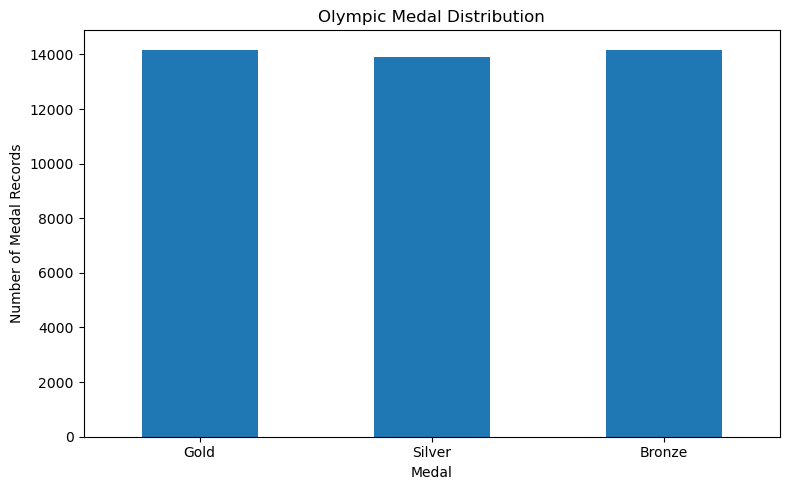

In [39]:
# 36. Medal distribution chart

plt.figure(figsize=(8, 5))
medal_counts.plot(kind="bar")
plt.title("Olympic Medal Distribution")
plt.xlabel("Medal")
plt.ylabel("Number of Medal Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


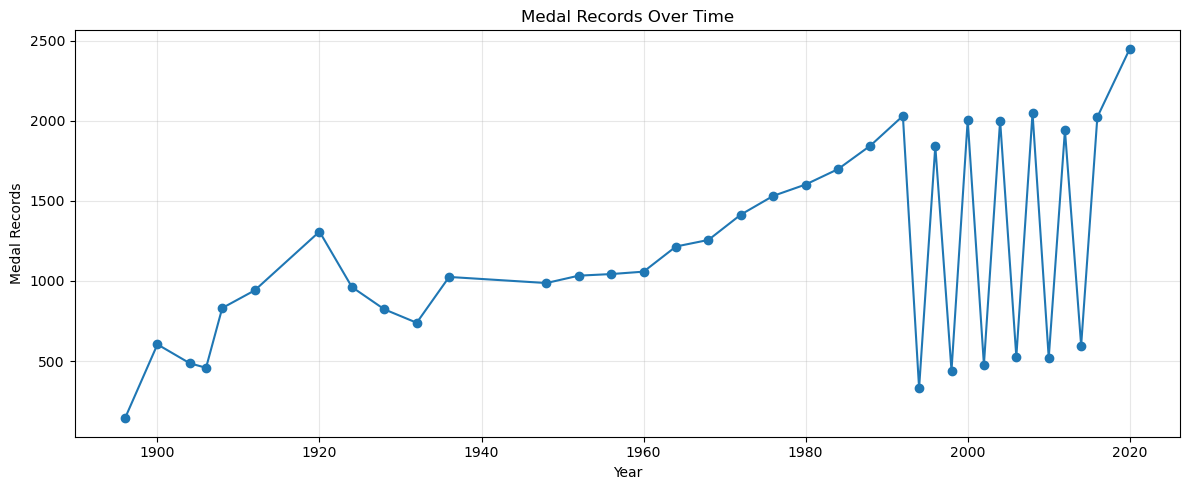

In [40]:
# 37. Medals by year

medals_by_year = (
    medal_data
    .groupby("Year")
    .size()
    .sort_index()
)

plt.figure(figsize=(12, 5))
medals_by_year.plot(kind="line", marker="o")
plt.title("Medal Records Over Time")
plt.xlabel("Year")
plt.ylabel("Medal Records")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [41]:
# 38. Medal counts by season

season_medals = pd.crosstab(
    medal_data["Season"],
    medal_data["Medal"]
).reindex(columns=["Gold", "Silver", "Bronze"], fill_value=0)

display(season_medals)


Medal,Gold,Silver,Bronze
Season,,,
Summer,12259,12002,12276
Winter,1913,1896,1886


# 7. Country / Region Analysis


In [42]:
# 39. Total medals by Region

country_total_medals = (
    medal_data
    .groupby("Region")
    .size()
    .sort_values(ascending=False)
)

display(country_total_medals.head(20))


Region
USA               5935
Russia            4096
Germany           3837
UK                2209
France            1918
Italy             1713
Sweden            1570
Australia         1480
Canada            1437
Hungary           1186
China             1142
Netherlands       1112
Norway            1056
Japan             1044
Finland            902
Switzerland        706
South Korea        676
Romania            662
Czech Republic     657
Denmark            630
dtype: int64

In [43]:
# 40. Gold, Silver, Bronze and Total by Region

country_medals = pd.crosstab(
    medal_data["Region"],
    medal_data["Medal"]
).reindex(columns=["Gold", "Silver", "Bronze"], fill_value=0)

country_medals["Total"] = country_medals.sum(axis=1)

country_medals = country_medals.sort_values(
    "Total",
    ascending=False
)

display(country_medals.head(20))


Medal,Gold,Silver,Bronze,Total
Region,,,,
USA,2751,1751,1433,5935
Russia,1640,1250,1206,4096
Germany,1322,1221,1294,3837
UK,719,782,708,2209
France,566,652,700,1918
Italy,597,548,568,1713
Sweden,485,550,535,1570
Australia,404,487,589,1480
Canada,499,449,489,1437


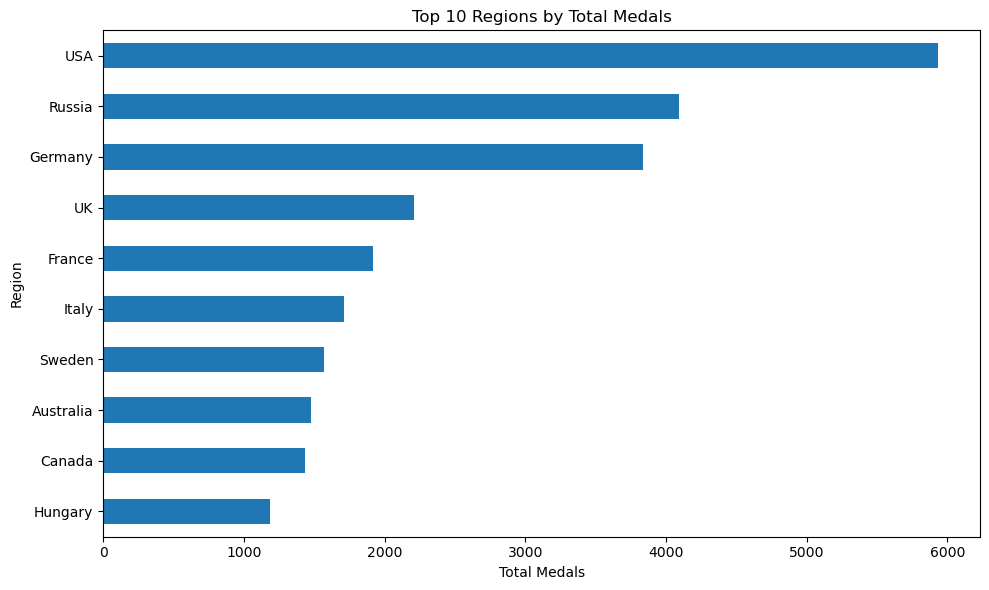

In [46]:
# 41. Top 10 Regions by total medals

top10_regions = country_medals.head(10).sort_values("Total")

plt.figure(figsize=(10, 6))
top10_regions["Total"].plot(kind="barh")
plt.title("Top 10 Regions by Total Medals")
plt.xlabel("Total Medals")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


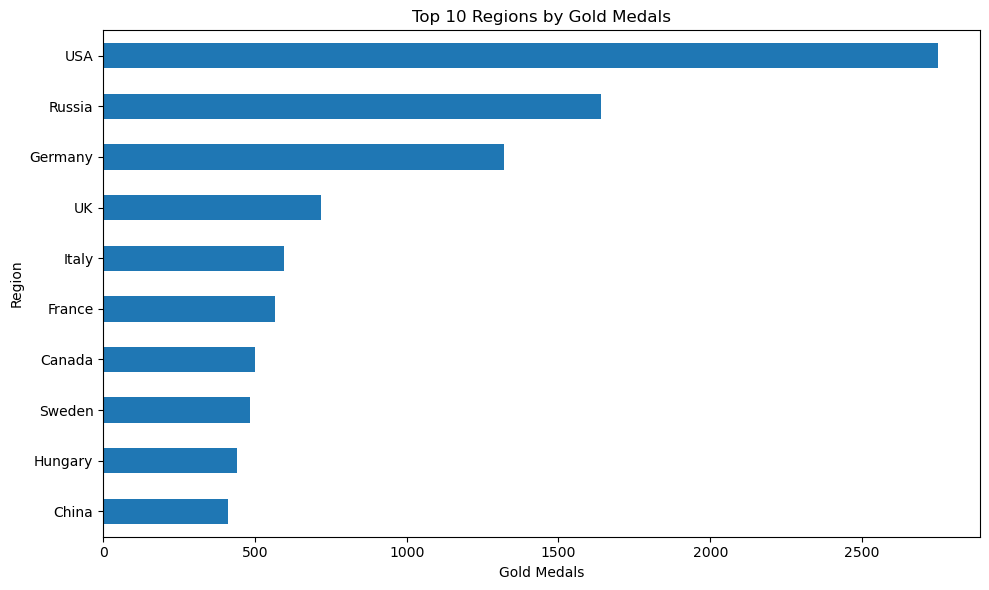

In [47]:
# 42. Top 10 Regions by Gold medals

top10_gold = country_medals.sort_values("Gold", ascending=False).head(10).sort_values("Gold")

plt.figure(figsize=(10, 6))
top10_gold["Gold"].plot(kind="barh")
plt.title("Top 10 Regions by Gold Medals")
plt.xlabel("Gold Medals")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


In [48]:
# 43. Country participation over time

country_participation = (
    participation_data
    .groupby(["Year", "Region"])["Name"]
    .nunique()
    .reset_index(name="Athletes")
)

display(country_participation.head(20))


,Year,Region,Athletes
0,1896,Australia,1
1,1896,Austria,3
2,1896,Denmark,3
3,1896,France,12
4,1896,Germany,19
5,1896,Greece,102
6,1896,Hungary,7
7,1896,Italy,1
8,1896,Sweden,1
9,1896,Switzerland,3


# 8. Sport and Event Analysis


In [49]:
# 44. Most represented sports

sport_participation = (
    result_data
    .groupby("Sport")["Name"]
    .nunique()
    .sort_values(ascending=False)
)

display(sport_participation.head(20))


Sport
Athletics        24094
Swimming          9641
Rowing            8206
Football          6769
Cycling           5819
Boxing            5542
Wrestling         5276
Shooting          5235
Sailing           4830
Fencing           4382
Hockey            4245
Gymnastics        4132
Ice Hockey        3882
Basketball        3700
Canoeing          3204
Judo              3114
Weightlifting     3077
Handball          3066
Water Polo        2885
Volleyball        2790
Name: Name, dtype: int64

In [50]:
# 45. Sports with the most medal records

sport_medals = (
    medal_data
    .groupby("Sport")
    .size()
    .sort_values(ascending=False)
)

display(sport_medals.head(20))


Sport
Athletics               4199
Swimming                3256
Rowing                  3089
Gymnastics              2256
Fencing                 1833
Football                1703
Hockey                  1636
Ice Hockey              1530
Wrestling               1368
Shooting                1282
Sailing                 1277
Cycling                 1263
Canoeing                1165
Handball                1153
Basketball              1152
Water Polo              1135
Volleyball              1041
Boxing                   996
Equestrianism            965
Cross Country Skiing     776
dtype: int64

In [51]:
# 46. Sports with the most gold medals

gold_by_sport = (
    medal_data[medal_data["Medal"] == "Gold"]
    .groupby("Sport")
    .size()
    .sort_values(ascending=False)
)

display(gold_by_sport.head(20))


Sport
Athletics               1422
Swimming                1169
Rowing                  1026
Gymnastics               791
Fencing                  624
Football                 559
Hockey                   554
Ice Hockey               508
Sailing                  465
Wrestling                431
Shooting                 428
Cycling                  424
Basketball               389
Canoeing                 388
Handball                 381
Water Polo               376
Volleyball               346
Equestrianism            324
Boxing                   265
Cross Country Skiing     256
dtype: int64

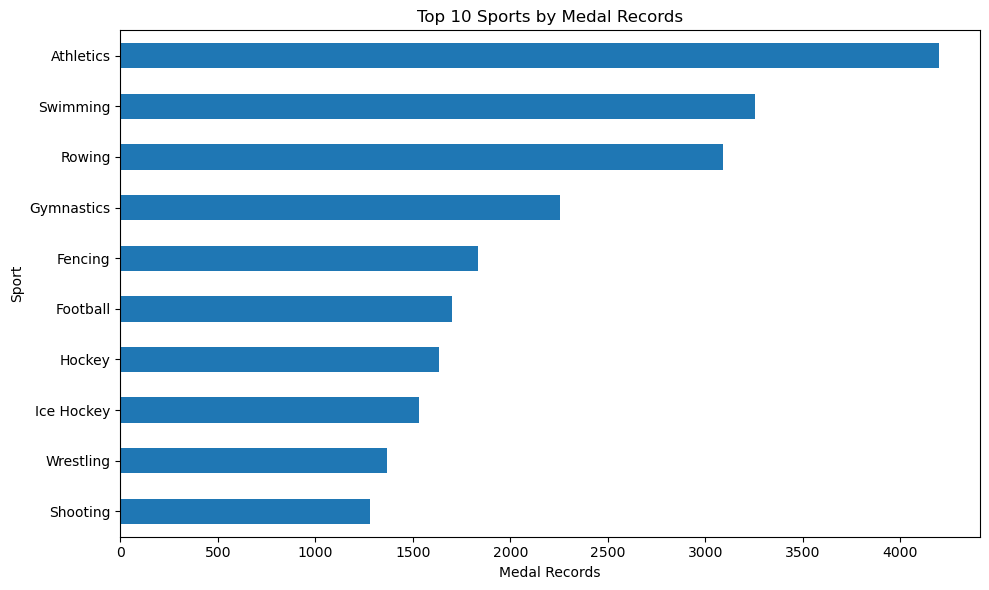

In [52]:
# 47. Top 10 sports by total medals

top10_sports = sport_medals.head(10).sort_values()

plt.figure(figsize=(10, 6))
top10_sports.plot(kind="barh")
plt.title("Top 10 Sports by Medal Records")
plt.xlabel("Medal Records")
plt.ylabel("Sport")
plt.tight_layout()
plt.show()


In [53]:
# 48. Top events by medal records

event_medals = (
    medal_data
    .groupby("Event")
    .size()
    .sort_values(ascending=False)
)

display(event_medals.head(20))


Event
Football Men's Football                            1269
Ice Hockey Men's Ice Hockey                        1230
Hockey Men's Hockey                                1050
Water Polo Men's Water Polo                         866
Rowing Men's Coxed Eights                           730
Gymnastics Men's Team All-Around                    713
Basketball Men's Basketball                         687
Handball Men's Handball                             588
Volleyball Men's Volleyball                         495
Hockey Women's Hockey                               478
Volleyball Women's Volleyball                       474
Handball Women's Handball                           472
Swimming Men's 4 x 200 metres Freestyle Relay       395
Basketball Women's Basketball                       393
Gymnastics Women's Team All-Around                  390
Fencing Men's epee, Team                            388
Fencing Men's Sabre, Team                           384
Swimming Women's 4 x 100 metres Freestyle 

# 9. Athlete Analysis


In [54]:
# 49. Athletes with the most medal records

top_athletes = (
    medal_data
    .groupby("Name")
    .size()
    .sort_values(ascending=False)
)

display(top_athletes.head(20))


Name
Michael Fred Phelps, II                            28
Larysa Semenivna Latynina (Diriy-)                 18
Nikolay Yefimovich Andrianov                       15
Ole Einar Bjrndalen                                13
Borys Anfiyanovych Shakhlin                        13
Edoardo Mangiarotti                                13
Takashi Ono                                        13
Dara Grace Torres (-Hoffman, -Minas)               12
Jennifer Elisabeth "Jenny" Thompson (-Cumpelik)    12
Natalie Anne Coughlin (-Hall)                      12
Birgit Fischer-Schmidt                             12
Sawao Kato                                         12
Aleksey Yuryevich Nemov                            12
Ryan Steven Lochte                                 12
Paavo Johannes Nurmi                               12
Vra slavsk (-Odloilov)                             11
Carl Townsend Osburn                               11
Matthew Nicholas "Matt" Biondi                     11
Aleksandr Vladimirovich

In [55]:
# 50. Athletes with the most gold medals

top_gold_athletes = (
    medal_data[medal_data["Medal"] == "Gold"]
    .groupby("Name")
    .size()
    .sort_values(ascending=False)
)

display(top_gold_athletes.head(20))


Name
Michael Fred Phelps, II                            23
Raymond Clarence "Ray" Ewry                        10
Paavo Johannes Nurmi                                9
Frederick Carlton "Carl" Lewis                      9
Mark Andrew Spitz                                   9
Larysa Semenivna Latynina (Diriy-)                  9
Ole Einar Bjrndalen                                 8
Usain St. Leo Bolt                                  8
Birgit Fischer-Schmidt                              8
Sawao Kato                                          8
Matthew Nicholas "Matt" Biondi                      8
Jennifer Elisabeth "Jenny" Thompson (-Cumpelik)     8
Vra slavsk (-Odloilov)                              7
Borys Anfiyanovych Shakhlin                         7
Viktor Ivanovych Chukarin                           7
Aladr Gerevich (-Gerei)                             7
Nikolay Yefimovich Andrianov                        7
Donald Arthur "Don" Schollander                     7
Gerard Theodor Hubert V

In [56]:
# 51. Athlete history function

def athlete_history(name):
    result = (
        df[df["Name"].str.casefold() == str(name).casefold()]
        .sort_values("Year")
    )
    return result[
        ["Name", "Gender", "Age", "Team", "NOC", "Region",
         "Year", "Season", "City", "Sport", "Event", "Medal"]
    ]

# Example:
# athlete_history("Michael Phelps")


# 10. Age Analysis


In [57]:
# 52. Age summary

display(age_data["Age"].describe())


count   287,876.00
mean         25.66
std           6.33
min          10.00
25%          22.00
50%          25.00
75%          28.00
max          97.00
Name: Age, dtype: float64

In [58]:
# 53. Average age by gender

average_age_gender = (
    age_data
    .groupby("Gender")["Age"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(average_age_gender)


,count,mean,median,min,max
Gender,,,,,
Female,86819,24.10,24.00,11.00,74.00
Male,201057,26.34,25.00,10.00,97.00


In [59]:
# 54. Average age by medal type

average_age_medal = (
    medal_data
    .groupby("Medal")["Age"]
    .agg(["count", "mean", "median", "min", "max"])
    .reindex(["Gold", "Silver", "Bronze"])
    .round(2)
)

display(average_age_medal)


,count,mean,median,min,max
Medal,,,,,
Gold,14024,25.96,25.00,13.00,64.00
Silver,13603,26.07,25.00,11.00,73.00
Bronze,13873,25.96,25.00,10.00,72.00


In [60]:
# 55. Young medalists: athletes under 20

young_medalists = medal_data[
    medal_data["Age"] < 20
].copy()

print("Medal records won by athletes under 20:", len(young_medalists))

display(
    young_medalists["Medal"]
    .value_counts()
    .reindex(["Gold", "Silver", "Bronze"], fill_value=0)
)


Medal records won by athletes under 20: 3505


Medal
Gold      1197
Silver    1167
Bronze    1141
Name: count, dtype: Int64

In [61]:
# 56. Top sports for medalists under 20

young_sport_medals = (
    young_medalists
    .groupby("Sport")
    .size()
    .sort_values(ascending=False)
)

display(young_sport_medals.head(10))


Sport
Swimming                     1155
Gymnastics                    496
Athletics                     219
Rowing                        131
Diving                        122
Boxing                        120
Football                      120
Rhythmic Gymnastics            90
Cycling                        85
Short Track Speed Skating      79
dtype: int64

In [62]:
# 57. Gold medals won by athletes under 20

young_gold_by_sport = (
    young_medalists[young_medalists["Medal"] == "Gold"]
    .groupby("Sport")
    .size()
    .sort_values(ascending=False)
)

display(young_gold_by_sport.head(10))


Sport
Swimming                     431
Gymnastics                   174
Athletics                     71
Rowing                        54
Diving                        47
Cycling                       34
Boxing                        34
Rhythmic Gymnastics           32
Football                      31
Short Track Speed Skating     30
dtype: int64

# 11. Historical Trends


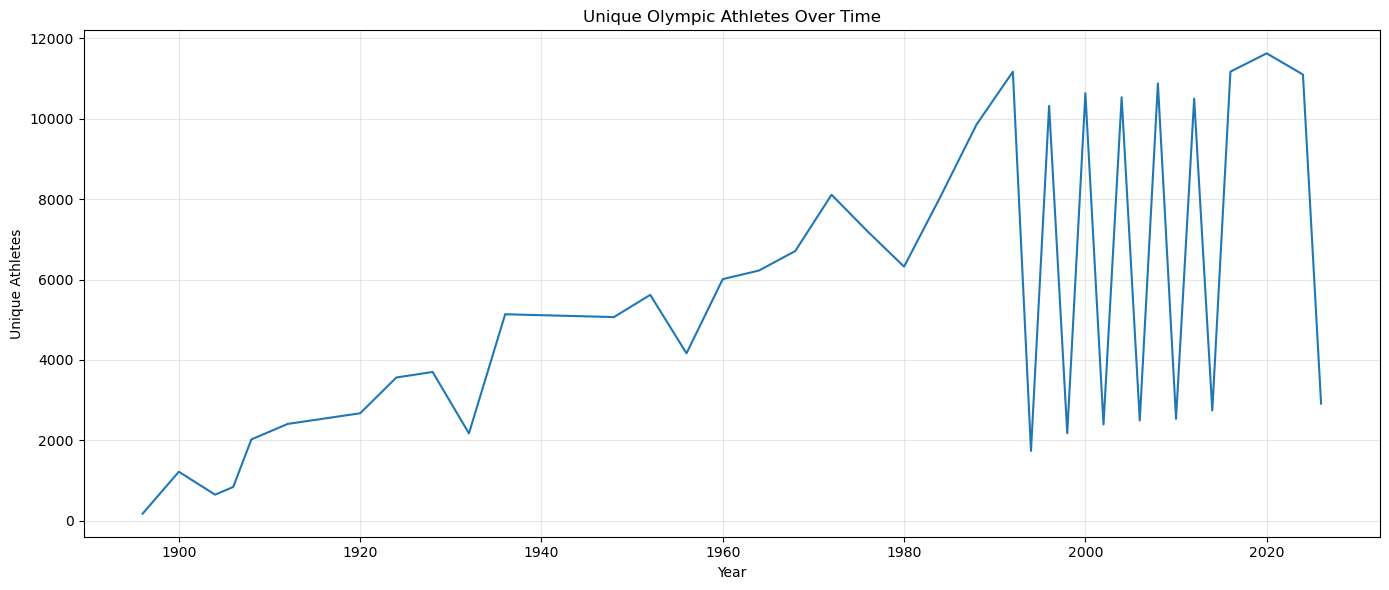

In [63]:
# 58. Unique athletes over time

unique_athletes_year = (
    participation_data
    .groupby("Year")["Name"]
    .nunique()
    .sort_index()
)

plt.figure(figsize=(14, 6))
unique_athletes_year.plot()
plt.title("Unique Olympic Athletes Over Time")
plt.xlabel("Year")
plt.ylabel("Unique Athletes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


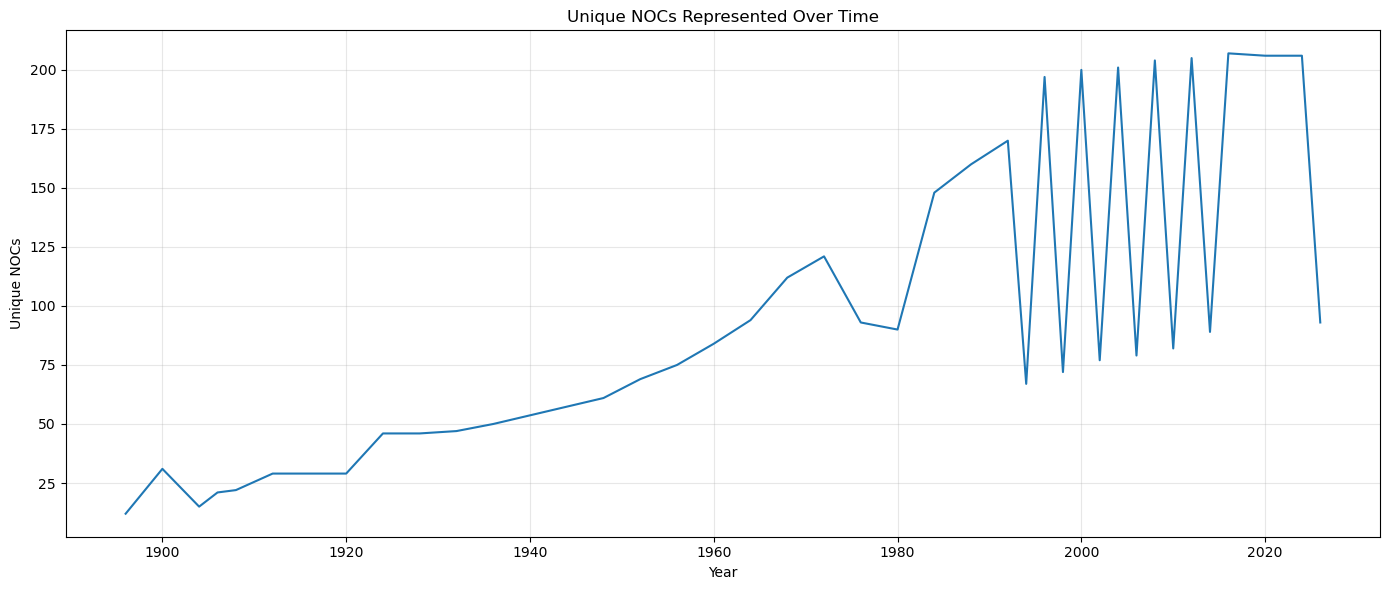

In [64]:
# 59. Unique NOCs over time

unique_nocs_year = (
    participation_data
    .groupby("Year")["NOC"]
    .nunique()
    .sort_index()
)

plt.figure(figsize=(14, 6))
unique_nocs_year.plot()
plt.title("Unique NOCs Represented Over Time")
plt.xlabel("Year")
plt.ylabel("Unique NOCs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


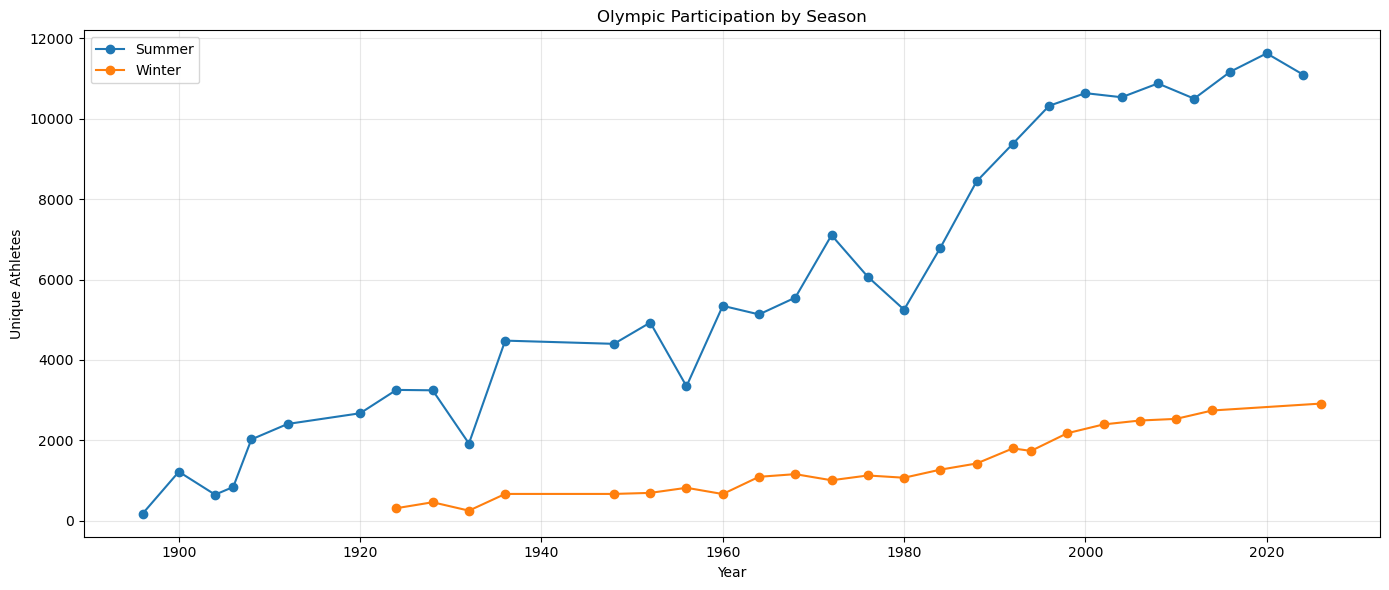

In [65]:
# 60. Summer vs Winter athlete participation

season_year = (
    participation_data
    .groupby(["Year", "Season"])["Name"]
    .nunique()
    .reset_index(name="Athletes")
)

plt.figure(figsize=(14, 6))

for season in season_year["Season"].dropna().unique():
    temp = season_year[season_year["Season"] == season]
    plt.plot(temp["Year"], temp["Athletes"], marker="o", label=season)

plt.title("Olympic Participation by Season")
plt.xlabel("Year")
plt.ylabel("Unique Athletes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


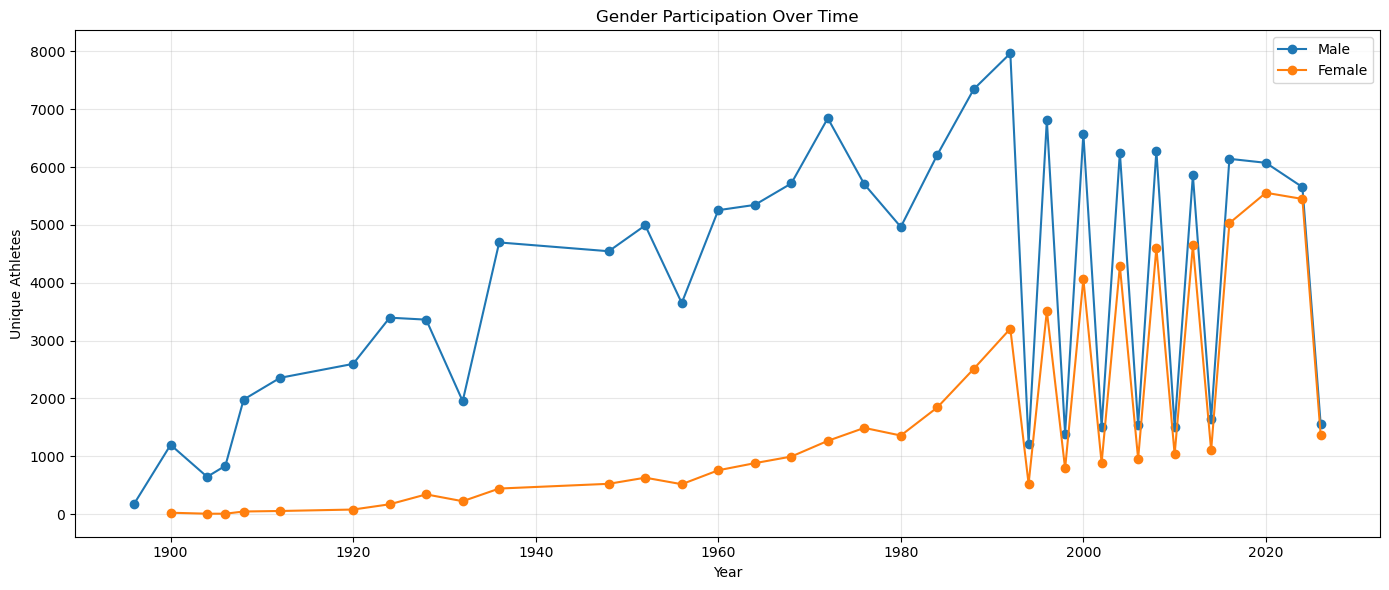

In [66]:
# 61. Gender participation trend

gender_trend = (
    participation_data
    .groupby(["Year", "Gender"])["Name"]
    .nunique()
    .reset_index(name="Athletes")
)

plt.figure(figsize=(14, 6))

for gender in gender_trend["Gender"].dropna().unique():
    temp = gender_trend[gender_trend["Gender"] == gender]
    plt.plot(temp["Year"], temp["Athletes"], marker="o", label=gender)

plt.title("Gender Participation Over Time")
plt.xlabel("Year")
plt.ylabel("Unique Athletes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 12. 2026 Data Quality Investigation

The supplied dataset contains 2026 records. However, the available 2026 records have missing Sport/Event/Medal information.

We therefore should **not interpret the 2026 rows as complete competition results**.

They can still be used for athlete/NOC participation information, but medal and sport-result analyses should exclude incomplete records.


In [67]:
# 62. 2026 overview

data_2026 = df[df["Year"] == 2026].copy()

print("2026 rows:", len(data_2026))
display(data_2026.head(20))


2026 rows: 2916


,Entry ID,Name,Gender,Age,Team,NOC,Year,Season,City,Sport,Event,Medal,Sport Disciplines,Event List,Region,Medal Won,Gold Medal,Silver Medal,Bronze Medal,Results Available
297350,297351,AABREKK Ingrid Bergene,Female,NaN,<NA>,NOR,2026,Winter,Italy,<NA>,<NA>,<NA>,<NA>,<NA>,Norway,False,<NA>,<NA>,<NA>,False
297351,297352,AAGAARD Mikkel,Male,NaN,<NA>,DEN,2026,Winter,Italy,<NA>,<NA>,<NA>,<NA>,<NA>,Denmark,False,<NA>,<NA>,<NA>,False
297352,297353,AALTO Antti,Male,NaN,<NA>,FIN,2026,Winter,Italy,<NA>,<NA>,<NA>,<NA>,<NA>,Finland,False,<NA>,<NA>,<NA>,False
297353,297354,ABATANGELO Aurora,Female,NaN,<NA>,ITA,2026,Winter,Italy,<NA>,<NA>,<NA>,<NA>,<NA>,Italy,False,<NA>,<NA>,<NA>,False
297354,297355,ABDI Fayik,Male,NaN,<NA>,KSA,2026,Winter,Italy,<NA>,<NA>,<NA>,<NA>,<NA>,Saudi Arabia,False,<NA>,<NA>,<NA>,False
297355,297356,ABDUL-SABOOR Hakeem,Male,NaN,<NA>,USA,2026,Winter,Italy,<NA>,<NA>,<NA>,<NA>,<NA>,USA,False,<NA>,<NA>,<NA>,False
297356,297357,ABEDA Shannon,Male,NaN,<NA>,ERI,2026,Winter,Italy,<NA>,<NA>,<NA>,<NA>,<NA>,Eritrea,False,<NA>,<NA>,<NA>,False
297357,297358,ABSTREITER Sandra,Female,NaN,<NA>,GER,2026,Winter,Italy,<NA>,<NA>,<NA>,<NA>,<NA>,Germany,False,<NA>,<NA>,<NA>,False
297358,297359,ACHLEITNER Lisa,Female,NaN,<NA>,AUT,2026,Winter,Italy,<NA>,<NA>,<NA>,<NA>,<NA>,Austria,False,<NA>,<NA>,<NA>,False
297359,297360,ADAKE Ahenaer,Female,NaN,<NA>,CHN,2026,Winter,Italy,<NA>,<NA>,<NA>,<NA>,<NA>,China,False,<NA>,<NA>,<NA>,False


In [68]:
# 63. 2026 completeness

completeness_2026 = pd.DataFrame({
    "Non-missing": data_2026.notna().sum(),
    "Missing": data_2026.isna().sum(),
    "Missing %": (data_2026.isna().mean() * 100).round(2)
})

display(completeness_2026)


,Non-missing,Missing,Missing %
Entry ID,2916,0,0.00
Name,2916,0,0.00
Gender,2916,0,0.00
Age,0,2916,100.00
Team,0,2916,100.00
NOC,2916,0,0.00
Year,2916,0,0.00
Season,2916,0,0.00
City,2916,0,0.00
Sport,0,2916,100.00


In [69]:
# 64. 2026 Sport/Event/Medal check

print("2026 Sport missing:", data_2026["Sport"].isna().sum())
print("2026 Event missing:", data_2026["Event"].isna().sum())
print("2026 Medal missing:", data_2026["Medal"].isna().sum())

print("\n2026 NOCs:")
display(data_2026["NOC"].value_counts().head(20))


2026 Sport missing: 2916
2026 Event missing: 2916
2026 Medal missing: 2916

2026 NOCs:


NOC
USA    235
CAN    209
ITA    196
GER    189
SUI    175
FRA    162
CHN    126
JPN    121
AUT    117
CZE    115
SWE    110
FIN    103
NOR     80
KOR     73
LAT     68
POL     60
GBR     55
AUS     53
SVK     53
UKR     46
Name: count, dtype: Int64

# 13. Data Quality Summary

Based on the supplied dataset inspection:

- The dataset contains **300,266 records and 14 columns**.
- There are **no exact duplicate rows** in the supplied output.
- The year range is **1896–2026**.
- There are both **Summer and Winter** records.
- `Medal` has many missing values and should not be treated as a standard missing-data error.
- `Age` has missing values and should be ignored only for analyses that require age.
- `Sport` and `Event` have missing values that are concentrated in newer/incomplete records, so sport/event analysis should use `result_data`.
- `Sport Disciplines` and `Event List` are highly sparse and should not replace `Sport` and `Event` as the primary analysis columns.
- The 2026 records should be handled separately because they do not represent complete competition-result data.


In [70]:
# 65. Final data-quality report

final_quality = pd.DataFrame({
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Unique Athletes": [df["Name"].nunique()],
    "Unique NOCs": [df["NOC"].nunique()],
    "Unique Regions": [df["Region"].nunique()],
    "Unique Sports": [result_data["Sport"].nunique()],
    "Unique Events": [result_data["Event"].nunique()],
    "Medal Records": [len(medal_data)],
    "Duplicate Rows": [df.duplicated().sum()],
    "Missing Age": [df["Age"].isna().sum()],
    "Missing Team": [df["Team"].isna().sum()],
    "Missing Sport": [df["Sport"].isna().sum()],
    "Missing Event": [df["Event"].isna().sum()],
    "Missing Medal": [df["Medal"].isna().sum()]
})

display(final_quality.T.rename(columns={0: "Value"}))


,Value
Rows,300266
Columns,20
Unique Athletes,159941
Unique NOCs,234
Unique Regions,207
Unique Sports,84
Unique Events,1071
Medal Records,42232
Duplicate Rows,0
Missing Age,12390


# 14. Key Questions for the Streamlit Dashboard

The analysis above can directly become dashboard pages:

### Dashboard
- Total athlete records
- Unique athletes
- NOCs/regions
- Sports
- Medal records
- Participation trend

### Medal Analysis
- Gold/Silver/Bronze totals
- Medals by year
- Top 10 regions
- Gold-medal leaders
- Medal distribution

### Country / Region Analysis
- Select a country/region
- Participation trend
- Total medals
- Gold/Silver/Bronze breakdown
- Best sports

### Athlete Analysis
- Search an athlete
- Olympic history
- Age
- Sports/events
- Medal history

### Sport Analysis
- Select a sport
- Participation
- Medal count
- Gold medals
- Top events

### Historical Trends
- Participation by year
- Summer vs Winter
- Gender participation
- NOC growth

### Data Explorer
- Filter by year, season, region, sport and medal
- Display filtered rows
- Download filtered data


In [71]:
# 66. Export analysis-ready datasets

# These files are optional. Uncomment if you want to create CSV outputs.

# df.to_csv("olympics_cleaned_merged.csv", index=False)
# participation_data.to_csv("olympics_participation_data.csv", index=False)
# result_data.to_csv("olympics_result_data.csv", index=False)
# medal_data.to_csv("olympics_medal_data.csv", index=False)

print("Notebook analysis complete.")


Notebook analysis complete.


# Conclusion

This notebook establishes a clean and defensible analysis workflow for the Olympics dataset.

The most important principle is to **avoid deleting records simply because they contain missing values**. Instead, the dataset is separated into participation, result, medal and age-specific views depending on the analytical question.

The resulting DataFrames are ready to be connected to the Streamlit application for interactive analysis.
